## Unifrom Scaled

In [1]:
using Distributions, Random, Statistics, MultipleTesting
using Empirikos, Hypatia, LinearAlgebra
using StatsPlots

Random.seed!(105)

# simulation parameters
n_values = [4, 5, 6, 8, 10, 20, 30, 40]
G = 1000
R = 100

p_signal = 0.1
β_signal = 4.0

# variance prior
s0_sq_true = 1.0
d0_true = 4.0

# storage
datasets = Dict{Tuple{Int,Int}, Any}()

function rand_scaled_uniform_errors(
    rng::AbstractRNG,
    n::Int
)
    a = -sqrt(3)
    b = sqrt(3)

    return rand(rng, Uniform(a, b), n)
end

for n in n_values
    for r in 1:R

        rng = MersenneTwister(10_000 + 100n + r)

        is_DE = rand(rng, G) .< p_signal

        σ2 = rand(
            rng,
            InverseGamma(d0_true / 2,
                         d0_true * s0_sq_true / 2),
            G
        )

        σ = sqrt.(σ2)

        Y = Vector{Vector{Float64}}(undef, G)

        @inbounds for i in 1:G

            # βi = is_DE[i] ? β_signal * σ[i] : 0.0
            βi = is_DE[i] ? β_signal * σ[i] / sqrt(n) : 0.0

            z = rand_scaled_uniform_errors(
                rng,
                n
            )

            Y[i] = βi .+ σ[i] .* z
        end


        datasets[(n,r)] = (
            Y = Y,
            is_DE = is_DE,
            σ = σ,
            σ2 = σ2,
            error_dist = "Variance-standardized Uniform",
            β_signal = β_signal,
            s0_sq_true = s0_sq_true,
            d0_true = d0_true
        )

    end
end

In [ ]:
limma_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[],
    "TP_top100" => Float64[]
)

# Store full per-gene p-values
limma_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()

# Store replicate-level top-100 results
limma_top100_store = Dict{Tuple{Int,Int}, Int}()


# =========================================================
# Loop over sample sizes
# =========================================================
for n in n_values

    println("\n========== Running LIMMA simulation for n = $n ==========")

    ν = n - 1

    power_vals  = Float64[]
    fdr_vals    = Float64[]
    tp_vals     = Float64[]
    fp_vals     = Float64[]
    top100_vals = Float64[]

    for r in 1:R

        try
            Y     = datasets[(n,r)].Y
            is_DE = datasets[(n,r)].is_DE
            σ     = datasets[(n,r)].σ

            # -------------------------------------------------
            # Per-gene statistics
            # -------------------------------------------------
            β_hat = [mean(Y[i]) for i in 1:G]

            s_hat = [
                std(Y[i], corrected=true)
                for i in 1:G
            ]

            se_hat_squared = (s_hat .^ 2) ./ n


            # -------------------------------------------------
            # LIMMA samples
            # -------------------------------------------------
            samples = [
                Empirikos.NormalChiSquareSample(
                    β_hat[i],
                    se_hat_squared[i],
                    ν
                )
                for i in 1:G
            ]


            # -------------------------------------------------
            # Fit LIMMA EB test
            # -------------------------------------------------
            test_limma = Empirikos.EmpiricalPartiallyBayesTTest(
                α = 0.05,
                prior = Empirikos.Limma(),
                solver = Hypatia.Optimizer
            )

            res_limma = fit(test_limma, samples)


            # -------------------------------------------------
            # Extract p-values and rejection decisions
            # -------------------------------------------------
            pvals_limma = res_limma.pvalue
            rej_limma   = res_limma.rj_idx


            # =================================================
            # SAVE THE RAW P-VALUES
            # =================================================
            limma_pvals_store[(n,r)] = copy(pvals_limma)


            # =================================================
            # Standard rejection-based metrics
            # =================================================
            TP = sum(rej_limma .& is_DE)
            FP = sum(rej_limma .& .!is_DE)

            power = TP / max(sum(is_DE), 1)

            fdr = FP / max(sum(rej_limma), 1)


            # =================================================
            # Ranking metric: true signals among top 100
            # =================================================
            k = min(100, G)

            ord = sortperm(pvals_limma)

            top_idx = ord[1:k]

            TP_top100 = sum(is_DE[top_idx])


            # Store replicate-level ranking result
            limma_top100_store[(n,r)] = TP_top100


            # -------------------------------------------------
            # Collect replicate metrics
            # -------------------------------------------------
            push!(tp_vals, TP)
            push!(fp_vals, FP)

            push!(power_vals, power)
            push!(fdr_vals, fdr)

            push!(top100_vals, TP_top100)


        catch err

            @warn "Skipping Rep $r for n=$n due to numerical error: $err"

            continue
        end
    end


    # =========================================================
    # Average over replicates
    # =========================================================
    mean_TP     = mean(tp_vals)
    mean_FP     = mean(fp_vals)

    mean_power  = mean(power_vals)
    mean_fdr    = mean(fdr_vals)

    mean_top100 = mean(top100_vals)


    push!(limma_summary["n"], n)

    push!(limma_summary["TP"], mean_TP)
    push!(limma_summary["FP"], mean_FP)

    push!(limma_summary["Power"], mean_power)
    push!(limma_summary["FDR"], mean_fdr)

    push!(limma_summary["TP_top100"], mean_top100)


    println(
        "n = $n → " *
        "Power=$(round(mean_power, digits=3)) | " *
        "FDR=$(round(mean_fdr, digits=3)) | " *
        "TP=$(round(mean_TP, digits=1)) | " *
        "FP=$(round(mean_FP, digits=1)) | " *
        "TP@100=$(round(mean_top100, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================
println("\n========== LIMMA SUMMARY ACROSS SAMPLE SIZES ==========")

for i in eachindex(limma_summary["n"])

    println(
        "n = $(limma_summary["n"][i]) → " *
        "Power=$(round(limma_summary["Power"][i], digits=5)), " *
        "FDR=$(round(limma_summary["FDR"][i], digits=5)), " *
        "TP@100=$(round(limma_summary["TP_top100"][i], digits=3))"
    )
end

In [3]:
using Distributions
using Statistics

# =========================================================
# Benjamini-Hochberg rejection rule
# =========================================================


# =========================================================
# Ordinary one-sample t-test
# =========================================================

ttest_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)


for n in n_values

    println("\n========== Running ordinary t-test for n = $n ==========")

    ν = n - 1

    power_vals = Float64[]
    fdr_vals   = Float64[]
    tp_vals    = Float64[]
    fp_vals    = Float64[]

    for r in 1:R

        Y     = datasets[(n,r)].Y
        is_DE = datasets[(n,r)].is_DE
            # 1. Compute sample mean and SD
        β_hat = [mean(Y[i]) for i in 1:G]
        s_hat = [std(Y[i], corrected=true) for i in 1:G]
        
        # 2. Ordinary t statistics
        t_stats = sqrt(n) .* β_hat ./ s_hat
        
        # 3. Two-sided p-values
        tdist = TDist(n - 1)
        pvals_t = 2 .* ccdf.(Ref(tdist), abs.(t_stats))
        
        # 4. BH-adjusted p-values
        adj_p = adjust(pvals_t, BenjaminiHochberg())
        
        # 5. Reject at FDR = 0.05
        rej_t = adj_p .<= 0.05
        
        # 6. Metrics
        TP = sum(rej_t .& is_DE)
        FP = sum(rej_t .& .!is_DE)
        
        power = TP / max(sum(is_DE), 1)
        fdr   = FP / max(sum(rej_t), 1)



        push!(tp_vals, TP)
        push!(fp_vals, FP)
        push!(power_vals, power)
        push!(fdr_vals, fdr)
    end


    # -----------------------------------------------------
    # Average across the R simulation replicates
    # -----------------------------------------------------

    mean_TP    = mean(tp_vals)
    mean_FP    = mean(fp_vals)
    mean_power = mean(power_vals)
    mean_fdr   = mean(fdr_vals)


    push!(ttest_summary["n"], n)
    push!(ttest_summary["TP"], mean_TP)
    push!(ttest_summary["FP"], mean_FP)
    push!(ttest_summary["Power"], mean_power)
    push!(ttest_summary["FDR"], mean_fdr)


    println(
        "n = $n → ",
        "Power=$(round(mean_power, digits=3)) | ",
        "FDR=$(round(mean_fdr, digits=3)) | ",
        "TP=$(round(mean_TP, digits=1)) | ",
        "FP=$(round(mean_FP, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================

println("\n========== ORDINARY T-TEST SUMMARY ==========")

for i in eachindex(ttest_summary["n"])

    println(
        "n = $(ttest_summary["n"][i]) → ",
        "TP=$(round(ttest_summary["TP"][i], digits=3)), ",
        "FP=$(round(ttest_summary["FP"][i], digits=3)), ",
        "Power=$(round(ttest_summary["Power"][i], digits=5)), ",
        "FDR=$(round(ttest_summary["FDR"][i], digits=5))"
    )
end


========== Running ordinary t-test for n = 4 ==========
n = 4 → Power=0.005 | FDR=0.214 | TP=0.5 | FP=0.4

========== Running ordinary t-test for n = 5 ==========
n = 5 → Power=0.016 | FDR=0.254 | TP=1.7 | FP=0.9

========== Running ordinary t-test for n = 6 ==========
n = 6 → Power=0.044 | FDR=0.226 | TP=4.5 | FP=1.5

========== Running ordinary t-test for n = 8 ==========
n = 8 → Power=0.191 | FDR=0.13 | TP=19.4 | FP=3.0

========== Running ordinary t-test for n = 10 ==========
n = 10 → Power=0.429 | FDR=0.088 | TP=43.6 | FP=4.4

========== Running ordinary t-test for n = 20 ==========
n = 20 → Power=0.754 | FDR=0.053 | TP=75.7 | FP=4.4

========== Running ordinary t-test for n = 30 ==========
n = 30 → Power=0.805 | FDR=0.053 | TP=79.4 | FP=4.6

========== Running ordinary t-test for n = 40 ==========
n = 40 → Power=0.829 | FDR=0.049 | TP=82.6 | FP=4.3

========== ORDINARY T-TEST SUMMARY ==========
n = 4 → TP=0.5, FP=0.43, Power=0.00517, FDR=0.21375
n = 5 → TP=1.67, FP=0.94, Power=0

In [6]:
using FastGaussQuadrature
using Distributions
using StatsFuns: logsumexp
using Optim
using MultipleTesting
using Statistics, Random, LinearAlgebra
using ApproxFun, SpecialFunctions

# =========================================================
# 1. Exact MAD-about-mean likelihood
# =========================================================

struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

import Distributions: pdf, logpdf, insupport, minimum, maximum

function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do
    G_recursive(n)
end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))
    z   = n * m / 2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n, k) * exp(-(m^2 * n^3) / (8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst * s
end

insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n
    z    = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G    = _getG(n)

    logs = Float64[]
    @inbounds for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            push!(logs,
                log(binomial(n, k)) -
                (m^2 * n^3) / (8σ^2 * k*(n-k)) +
                log(val1) + log(val2)
            )
        end
    end

    return -log(σ) + logC + (isempty(logs) ? -Inf : logsumexp(logs))
end

# =========================================================
# 2. Parametric prior on sigma^2
# =========================================================

struct InverseScaledChiSquare{T,S} <: ContinuousUnivariateDistribution
    σ²::T
    ν::S
end

function Distributions.InverseGamma(d::InverseScaledChiSquare)
    InverseGamma(d.ν / 2, d.ν * d.σ² / 2)
end

Distributions.pdf(d::InverseScaledChiSquare, x::Real) = pdf(InverseGamma(d), x)
Distributions.logpdf(d::InverseScaledChiSquare, x::Real) = logpdf(InverseGamma(d), x)

prior_sigma2(σ0², ν0) = InverseScaledChiSquare(σ0², ν0)

# =========================================================
# 3. Gauss-Legendre quadrature on (0,1)
# =========================================================

function gausslegendre01(K::Int)
    x, w = gausslegendre(K)   # nodes/weights on [-1,1]
    u = (x .+ 1) ./ 2         # map to (0,1)
    w = w ./ 2
    return u, w
end

# =========================================================
# 4. Marginal likelihood by Gauss-Legendre quadrature
#    transform s2 = u/(1-u), u in (0,1)
# =========================================================
function marginal_mad_logdensity_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logvals = similar(u_nodes)
    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        jac = 1 / (1 - u)^2

        logvals[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    return logsumexp(logvals)
end

# =========================================================
# 5. Negative log marginal likelihood across genes
# =========================================================

function negloglik_mad_parametric_gl(
    par::Vector{Float64},
    mad_obs::Vector{Float64},
    n::Int,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    η, ξ = par
    σ0² = exp(η)
    ν0  = exp(ξ)

    total = 0.0
    @inbounds for D in mad_obs
        total -= marginal_mad_logdensity_gl(D, n, σ0², ν0, u_nodes, u_weights)
    end
    return total
end

# =========================================================
# 6. Fit prior hyperparameters by Gaussian quadrature
# =========================================================

function fit_mad_parametric_prior_gl(
    mad_obs::Vector{Float64},
    n::Int;
    K_quad::Int = 64,
    init_logσ0² = log(max(median(mad_obs)^2, 1e-6)),
    init_logν0  = log(10.0),
    max_iter::Int = 80
)
    u_nodes, u_weights = gausslegendre01(K_quad)

    obj(par) = negloglik_mad_parametric_gl(par, mad_obs, n, u_nodes, u_weights)

    res = optimize(
        obj,
        [init_logσ0², init_logν0],
        NelderMead(),
        Optim.Options(iterations=max_iter, show_trace=false)
    )

    ηhat, ξhat = Optim.minimizer(res)

    return (
        σ0² = exp(ηhat),
        ν0  = exp(ξhat),
        optim = res,
        u_nodes = u_nodes,
        u_weights = u_weights
    )
end

# =========================================================
# 7. Posterior weights on same quadrature nodes
# =========================================================

function posterior_sigma2_weights_mad_gl(
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    prior = prior_sigma2(σ0², ν0)

    logpost = similar(u_nodes)
    s2_nodes = similar(u_nodes)

    @inbounds for j in eachindex(u_nodes)
        u = clamp(u_nodes[j], 1e-12, 1 - 1e-12)
        s2 = u / (1 - u)
        s2_nodes[j] = s2
        jac = 1 / (1 - u)^2

        logpost[j] =
            logpdf(MADDistribution(sqrt(s2), n), D) +
            logpdf(prior, s2) +
            log(jac) +
            log(u_weights[j])
    end

    m = maximum(logpost)
    w = exp.(logpost .- m)
    w ./= sum(w)

    return s2_nodes, w
end

# =========================================================
# 8. Posterior-averaged p-value
# =========================================================

function mad_parametric_pvalue_gl(
    β_tilde::Float64,
    D::Float64,
    n::Int,
    σ0²::Float64,
    ν0::Float64,
    u_nodes::Vector{Float64},
    u_weights::Vector{Float64}
)
    s2_nodes, w = posterior_sigma2_weights_mad_gl(D, n, σ0², ν0, u_nodes, u_weights)
    σ_nodes = sqrt.(s2_nodes)
    tails = 2 .* ccdf.(Normal.(0, σ_nodes), abs(β_tilde))
    return dot(tails, w)
end


mad_parametric_pvalue_gl (generic function with 1 method)

In [7]:
using FastGaussQuadrature
using Distributions
using Statistics
using MultipleTesting

# =========================================================
# Precompute quadrature for the exact MAD-normalized null
#
# Integral:
#
# p(t) = ∫ 2 Φbar(|t| c_n w) f_D(w | sigma=1,n) dw
#
# Transform:
#     w = u / (1-u),   u ∈ (0,1)
# =========================================================

function build_mad_null_quadrature(
    n::Int;
    K::Int = 400
)

    # Gauss-Legendre on [-1,1]
    x, qweights = gausslegendre(K)

    # Map to (0,1)
    u = (x .+ 1) ./ 2
    qweights ./= 2

    # Transform (0,1) -> (0,Inf)
    w_nodes = u ./ (1 .- u)

    jac = 1 ./ (1 .- u).^2

    # Exact MAD density evaluated ONLY ONCE
    mad_density = [
        pdf(
            MADDistribution(1.0, n),
            w
        )
        for w in w_nodes
    ]

    # Complete integration weights
    weights =
        qweights .* jac .* mad_density

    # Optional normalization to remove tiny numerical integration error
    weights ./= sum(weights)

    c_n =
        sqrt(pi / 2) *
        sqrt(n / (n - 1))

    return (
        w = w_nodes,
        weights = weights,
        c_n = c_n
    )
end

mad_quad_store =
    Dict{Int, Any}()

for n in n_values

    println(
        "Precomputing MAD null quadrature for n = $n"
    )

    @time mad_quad_store[n] =
        build_mad_null_quadrature(
            n;
            K = 400
        )
end

function mad_H_pvalue_fast(
    h_obs::Real,
    quad
)
    x = abs(h_obs)

    tails =
        2 .* ccdf.(
            Normal(),
            x .* quad.w
        )

    p = dot(
        quad.weights,
        tails
    )

    return clamp(p, 0.0, 1.0)
end

Precomputing MAD null quadrature for n = 4
  2.639125 seconds (30.69 M allocations: 1.554 GiB, 12.77% gc time, 99.48% compilation time)
Precomputing MAD null quadrature for n = 5
  0.004479 seconds (13.42 k allocations: 901.188 KiB)
Precomputing MAD null quadrature for n = 6
  0.005570 seconds (16.33 k allocations: 990.672 KiB)
Precomputing MAD null quadrature for n = 8
  0.006408 seconds (22.11 k allocations: 1.271 MiB)
Precomputing MAD null quadrature for n = 10
  0.007222 seconds (27.86 k allocations: 1.615 MiB)
Precomputing MAD null quadrature for n = 20
  0.011190 seconds (62.64 k allocations: 3.528 MiB)
Precomputing MAD null quadrature for n = 30
  0.014338 seconds (95.34 k allocations: 5.621 MiB)
Precomputing MAD null quadrature for n = 40
  0.038445 seconds (129.46 k allocations: 7.708 MiB, 31.73% gc time, 22.23% compilation time)


mad_H_pvalue_fast (generic function with 1 method)

In [8]:
mad_test_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

for n in n_values

    println(
        "\n========== Running MAD-normalized test for n = $n =========="
    )

    # Quadrature is already computed
    quad =
        mad_quad_store[n]

    power_vals = Float64[]
    fdr_vals   = Float64[]
    tp_vals    = Float64[]
    fp_vals    = Float64[]

    for r in 1:R

        Y =
            datasets[(n,r)].Y

        is_DE =
            datasets[(n,r)].is_DE

        # ---------------------------------------------
        # 1. Sample means
        # ---------------------------------------------

        β_hat = [
            mean(Y[i])
            for i in 1:G
        ]

        # ---------------------------------------------
        # 2. MAD about sample mean
        # ---------------------------------------------

        mad_obs = [
            mean(
                abs.(
                    Y[i] .- β_hat[i]
                )
            )
            for i in 1:G
        ]
        h_mad =
            sqrt(n) .* β_hat ./ mad_obs

        # ---------------------------------------------
        # 3. MAD estimate of sigma
        # ---------------------------------------------

        # sigma_hat_mad =
        #     quad.c_n .* mad_obs

        # # ---------------------------------------------
        # # 4. MAD-normalized statistic
        # # ---------------------------------------------

        # t_mad =
        #     sqrt(n) .* β_hat ./
        #     sigma_hat_mad

        # ---------------------------------------------
        # 5. Exact numerical p-values
        #    using precomputed quadrature
        # ---------------------------------------------

        # pvals_mad = [
        #     mad_normalized_pvalue_fast(
        #         t,
        #         quad
        #     )
        #     for t in t_mad
        # ]
        pvals_mad = [
            mad_H_pvalue_fast(h, quad)
            for h in h_mad
        ]

        # ---------------------------------------------
        # 6. BH adjustment
        # ---------------------------------------------

        adj_p =
            adjust(
                pvals_mad,
                BenjaminiHochberg()
            )

        rej_mad =
            adj_p .<= 0.05

        # ---------------------------------------------
        # 7. Performance
        # ---------------------------------------------

        TP =
            sum(rej_mad .& is_DE)

        FP =
            sum(rej_mad .& .!is_DE)

        power =
            TP / max(sum(is_DE), 1)

        fdp =
            FP / max(sum(rej_mad), 1)

        push!(tp_vals, TP)
        push!(fp_vals, FP)
        push!(power_vals, power)
        push!(fdr_vals, fdp)
    end

    # ---------------------------------------------
    # Average across replicates
    # ---------------------------------------------

    mean_TP =
        mean(tp_vals)

    mean_FP =
        mean(fp_vals)

    mean_power =
        mean(power_vals)

    mean_fdr =
        mean(fdr_vals)

    push!(
        mad_test_summary["n"],
        n
    )

    push!(
        mad_test_summary["TP"],
        mean_TP
    )

    push!(
        mad_test_summary["FP"],
        mean_FP
    )

    push!(
        mad_test_summary["Power"],
        mean_power
    )

    push!(
        mad_test_summary["FDR"],
        mean_fdr
    )

    println(
        "n = $n → ",
        "Power=$(round(mean_power,digits=3)) | ",
        "FDR=$(round(mean_fdr,digits=3)) | ",
        "TP=$(round(mean_TP,digits=1)) | ",
        "FP=$(round(mean_FP,digits=1))"
    )
end


println(
    "\n========== MAD NORMALIZED TEST SUMMARY =========="
)

for i in eachindex(mad_test_summary["n"])

    println(
        "n = $(mad_test_summary["n"][i]) → ",
        "TP=$(round(mad_test_summary["TP"][i],digits=3)), ",
        "FP=$(round(mad_test_summary["FP"][i],digits=3)), ",
        "Power=$(round(mad_test_summary["Power"][i],digits=5)), ",
        "FDR=$(round(mad_test_summary["FDR"][i],digits=5))"
    )
end


========== Running MAD-normalized test for n = 4 ==========
n = 4 → Power=0.005 | FDR=0.217 | TP=0.5 | FP=0.4

========== Running MAD-normalized test for n = 5 ==========
n = 5 → Power=0.014 | FDR=0.227 | TP=1.4 | FP=0.8

========== Running MAD-normalized test for n = 6 ==========
n = 6 → Power=0.037 | FDR=0.223 | TP=3.8 | FP=1.4

========== Running MAD-normalized test for n = 8 ==========
n = 8 → Power=0.138 | FDR=0.137 | TP=14.0 | FP=2.3

========== Running MAD-normalized test for n = 10 ==========
n = 10 → Power=0.288 | FDR=0.087 | TP=29.4 | FP=3.1

========== Running MAD-normalized test for n = 20 ==========
n = 20 → Power=0.601 | FDR=0.045 | TP=60.5 | FP=3.0

========== Running MAD-normalized test for n = 30 ==========
n = 30 → Power=0.687 | FDR=0.04 | TP=67.9 | FP=2.9

========== Running MAD-normalized test for n = 40 ==========
n = 40 → Power=0.722 | FDR=0.034 | TP=72.0 | FP=2.6

========== MAD NORMALIZED TEST SUMMARY ==========
n = 4 → TP=0.49, FP=0.41, Power=0.00502, FDR=0.21

In [9]:
using JLD2

@load "main_method_summaries(5.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps

7-element Vector{Symbol}:
 :simulation_params
 :limma_summary
 :epb_summary
 :mad_summary
 :mad_param_gl_summary
 :mad_param_gl_prior_summary
 :mad_param_gl_prior_reps

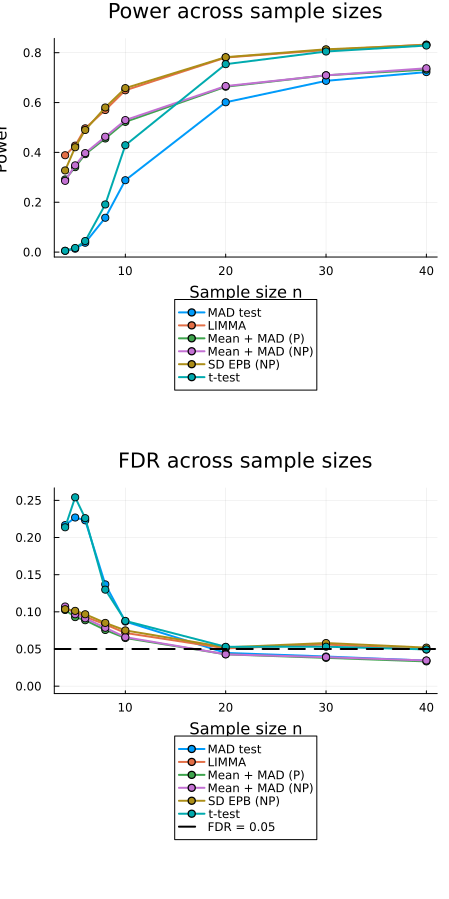

In [11]:
using Plots

# -------------------------------------------------
# 1. Build a common method dictionary
# -------------------------------------------------
method_summaries = Dict(
    "t-test"          => ttest_summary,
    "MAD test"        => mad_test_summary,
    "LIMMA"           => limma_summary,
    "SD EPB (NP)"     => epb_summary,
    "Mean + MAD (P)"  => mad_param_gl_summary,
    "Mean + MAD (NP)" => mad_summary
)

# compute max FDR across all methods
max_fdr = maximum(
    vcat([summ["FDR"] for summ in values(method_summaries)]...)
)
fdr_upper = max(0.06, 1.05 * max_fdr)

# -------------------------------------------------
# 2. Power plot
# -------------------------------------------------
p_power = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in method_summaries
    plot!(
        p_power,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

# -------------------------------------------------
# 3. FDR plot
# -------------------------------------------------
p_fdr = plot(
    xlabel = "Sample size n",
    ylabel = "FDR",
    title = "FDR across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle,
    ylims = (-0.01, fdr_upper)
)

for (method, summ) in method_summaries
    plot!(
        p_fdr,
        summ["n"],
        summ["FDR"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

hline!(
    p_fdr,
    [0.05];
    label = "FDR = 0.05",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 4. Show side by side
# -------------------------------------------------
plot(
    p_power,
    p_fdr;
    layout = (2, 1),
    size = (450, 900)
)

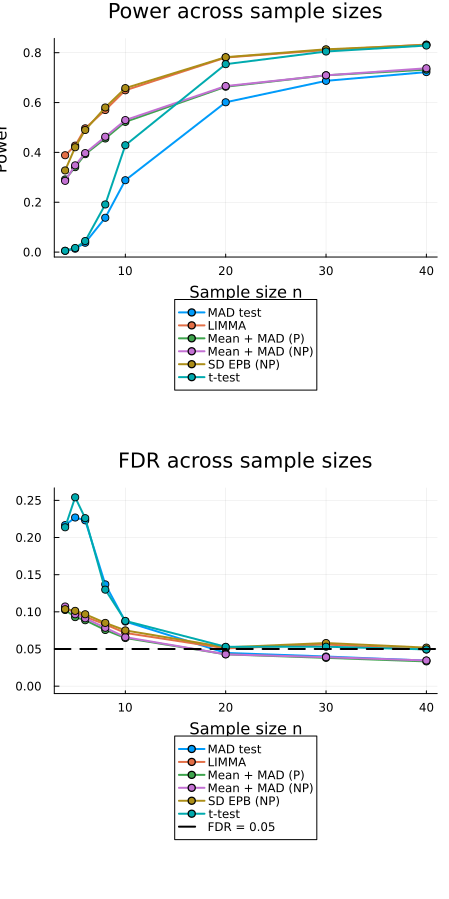

In [14]:
using Plots

# -------------------------------------------------
# 1. Build a common method dictionary
# -------------------------------------------------
method_summaries = Dict(
    "t-test"          => ttest_summary,
    "MAD test"        => mad_test_summary,
    "LIMMA"           => limma_summary,
    "SD EPB (NP)"     => epb_summary,
    "Mean + MAD (P)"  => mad_param_gl_summary,
    "Mean + MAD (NP)" => mad_summary
)

# compute max FDR across all methods
max_fdr = maximum(
    vcat([summ["FDR"] for summ in values(method_summaries)]...)
)
fdr_upper = max(0.06, 1.05 * max_fdr)

# -------------------------------------------------
# 2. Power plot
# -------------------------------------------------
p_power = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in method_summaries
    plot!(
        p_power,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

# -------------------------------------------------
# 3. FDR plot
# -------------------------------------------------
p_fdr = plot(
    xlabel = "Sample size n",
    ylabel = "FDR",
    title = "FDR across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle,
    ylims = (-0.01, fdr_upper)
)

for (method, summ) in method_summaries
    plot!(
        p_fdr,
        summ["n"],
        summ["FDR"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

hline!(
    p_fdr,
    [0.05];
    label = "FDR = 0.05",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 4. Show side by side
# -------------------------------------------------
plot(
    p_power,
    p_fdr;
    layout = (2, 1),
    size = (450, 900)
)

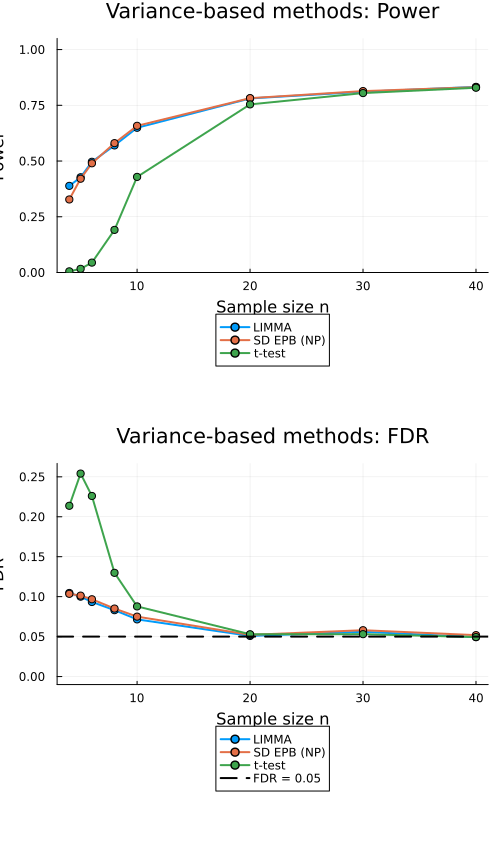

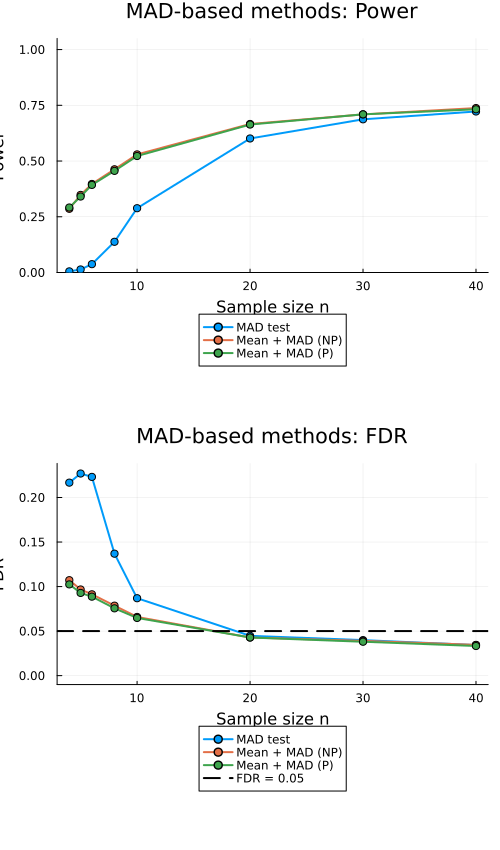

In [15]:
using Plots

# =========================================================
# 1. Separate methods into variance-based and MAD-based
# =========================================================

variance_summaries = Dict(
    "t-test"      => ttest_summary,
    "LIMMA"       => limma_summary,
    "SD EPB (NP)" => epb_summary
)

mad_summaries = Dict(
    "MAD test"        => mad_test_summary,
    "Mean + MAD (P)"  => mad_param_gl_summary,
    "Mean + MAD (NP)" => mad_summary
)


# =========================================================
# 2. Helper function: Power + FDR for one family
# =========================================================

function make_method_plot(method_summaries, family_title)

    # ---------------------------------------------
    # Maximum FDR for this family
    # ---------------------------------------------
    max_fdr = maximum(
        vcat([
            summ["FDR"]
            for summ in values(method_summaries)
        ]...)
    )

    fdr_upper = max(0.06, 1.05 * max_fdr)


    # ---------------------------------------------
    # Power
    # ---------------------------------------------
    p_power = plot(
        xlabel = "Sample size n",
        ylabel = "Power",
        title = "$family_title: Power",
        legend = :outerbottom,
        lw = 2,
        marker = :circle,
        ylim = (0, 1.05)
    )

    for (method, summ) in method_summaries
        plot!(
            p_power,
            summ["n"],
            summ["Power"];
            label = method,
            lw = 2,
            marker = :circle
        )
    end


    # ---------------------------------------------
    # FDR
    # ---------------------------------------------
    p_fdr = plot(
        xlabel = "Sample size n",
        ylabel = "FDR",
        title = "$family_title: FDR",
        legend = :outerbottom,
        lw = 2,
        marker = :circle,
        ylim = (-0.01, fdr_upper)
    )

    for (method, summ) in method_summaries
        plot!(
            p_fdr,
            summ["n"],
            summ["FDR"];
            label = method,
            lw = 2,
            marker = :circle
        )
    end

    hline!(
        p_fdr,
        [0.05];
        label = "FDR = 0.05",
        lw = 2,
        ls = :dash,
        color = :black
    )


    # ---------------------------------------------
    # Combine Power + FDR
    # ---------------------------------------------
    return plot(
        p_power,
        p_fdr;
        layout = (2, 1),
        size = (500, 850)
    )
end


# =========================================================
# 3. Variance-based methods
# =========================================================

p_variance = make_method_plot(
    variance_summaries,
    "Variance-based methods"
)

display(p_variance)


# =========================================================
# 4. MAD-based methods
# =========================================================

p_mad = make_method_plot(
    mad_summaries,
    "MAD-based methods"
)

display(p_mad)

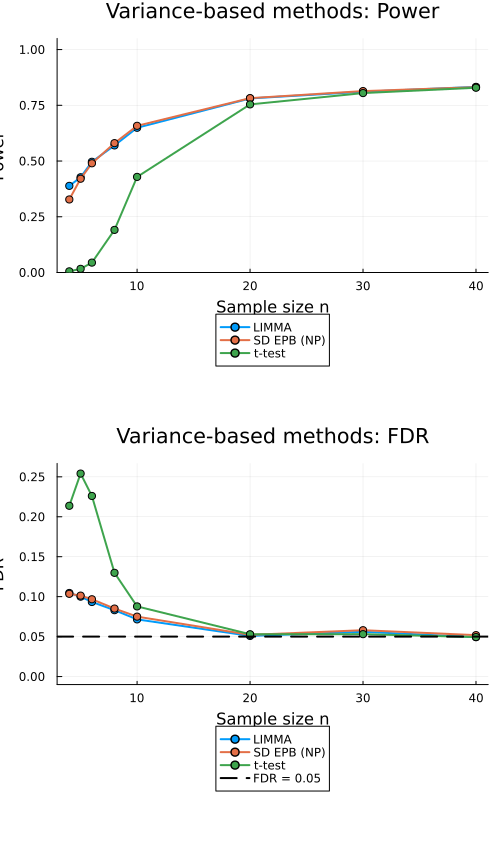

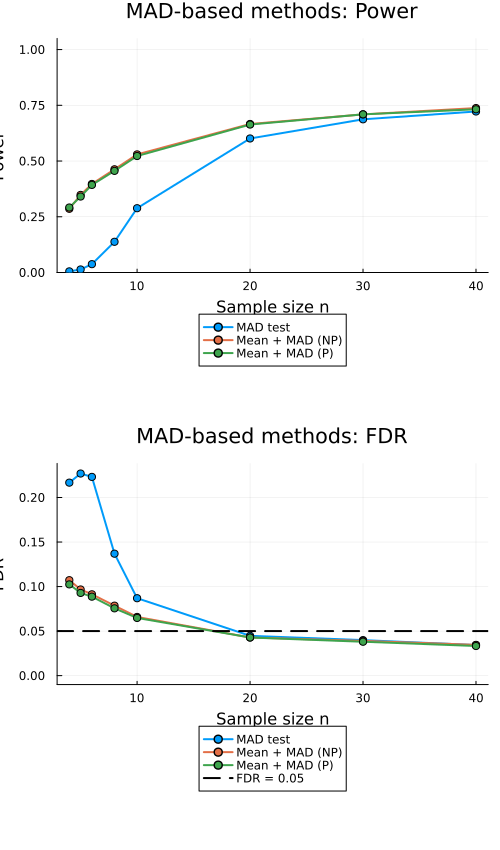

In [13]:
using JLD2

# =========================================================
# Save all Uniform results
# =========================================================

uniform_all_results = (
    ttest     = ttest_summary,
    mad_test  = mad_test_summary,
    limma     = limma_summary,
    epb       = epb_summary,
    mad_param = mad_param_gl_summary,
    mad_np    = mad_summary
)

uniform_params = (
    error_dist = "Uniform",
    n_values = [4, 5, 6, 8, 10, 20, 30, 40],
    G = 1000,
    R = 100,
    p_signal = 0.1,
    beta_signal = 4.0,
    s0_sq_true = 1.0,
    d0_true = 4.0
)

@save "uniform_all_results.jld2" uniform_all_results uniform_params

println("Saved uniform_all_results.jld2")

Saved uniform_all_results.jld2


In [12]:
# =========================================================
# Print Power and FDR for all methods
# =========================================================

methods = [
    ("t-test",          ttest_summary),
    ("MAD test",        mad_test_summary),
    ("LIMMA",           limma_summary),
    ("SD EPB (NP)",     epb_summary),
    ("Mean + MAD (P)",  mad_param_gl_summary),
    ("Mean + MAD (NP)", mad_summary)
]

# Collect all sample sizes
all_n = sort(unique(vcat([
    summ["n"] for (_, summ) in methods
]...)))

println("\n================ ALL METHOD RESULTS ================\n")

for n in all_n

    println("--------------------------------------------------")
    println("n = $n")
    println("--------------------------------------------------")

    for (method, summ) in methods

        idx = findfirst(==(n), summ["n"])

        if idx !== nothing
            power = summ["Power"][idx]
            fdr   = summ["FDR"][idx]

            println(
                rpad(method, 18),
                " Power = ",
                round(power, digits = 5),
                "   FDR = ",
                round(fdr, digits = 5)
            )
        end
    end

    println()
end


================ ALL METHOD RESULTS ================

--------------------------------------------------
n = 4
--------------------------------------------------
t-test             Power = 0.00517   FDR = 0.21375
MAD test           Power = 0.00502   FDR = 0.21668
LIMMA              Power = 0.3886   FDR = 0.10462
SD EPB (NP)        Power = 0.32762   FDR = 0.10353
Mean + MAD (P)     Power = 0.29151   FDR = 0.10244
Mean + MAD (NP)    Power = 0.28577   FDR = 0.10717

--------------------------------------------------
n = 5
--------------------------------------------------
t-test             Power = 0.01638   FDR = 0.25408
MAD test           Power = 0.01355   FDR = 0.22691
LIMMA              Power = 0.42718   FDR = 0.1
SD EPB (NP)        Power = 0.42063   FDR = 0.1013
Mean + MAD (P)     Power = 0.34073   FDR = 0.09286
Mean + MAD (NP)    Power = 0.34804   FDR = 0.09673

--------------------------------------------------
n = 6
--------------------------------------------------
t-test       

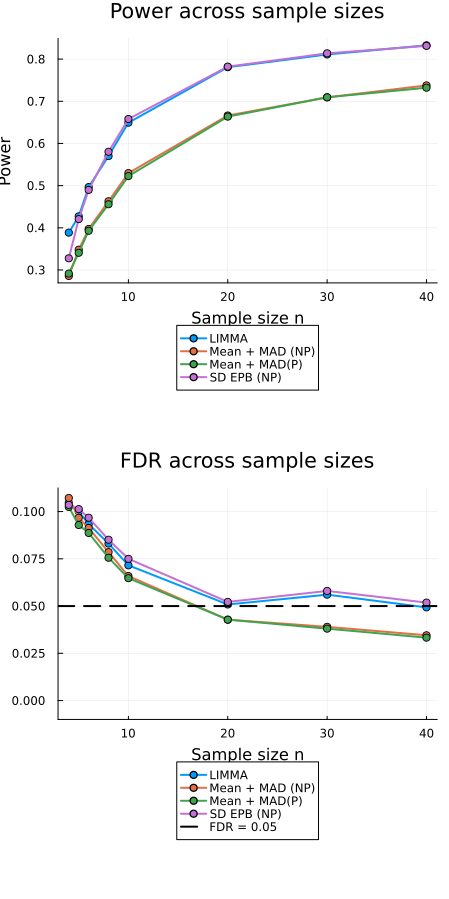

In [10]:
using Plots

# -------------------------------------------------
# 1. Build a common method dictionary
# -------------------------------------------------
method_summaries = Dict(
    "LIMMA" => limma_summary,
    "SD EPB (NP)" => epb_summary,
    "Mean + MAD (NP)" => mad_summary,
    "Mean + MAD(P)" => mad_param_gl_summary
)

# compute max FDR across all methods
max_fdr = maximum(vcat([summ["FDR"] for summ in values(method_summaries)]...))
fdr_upper = max(0.06, 1.05 * max_fdr)

# -------------------------------------------------
# 2. Power plot
# -------------------------------------------------
p_power = plot(
    xlabel = "Sample size n",
    ylabel = "Power",
    title = "Power across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle
)

for (method, summ) in method_summaries
    plot!(
        p_power,
        summ["n"],
        summ["Power"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

# -------------------------------------------------
# 3. FDR plot
# -------------------------------------------------
p_fdr = plot(
    xlabel = "Sample size n",
    ylabel = "FDR",
    title = "FDR across sample sizes",
    legend = :outerbottom,
    lw = 2,
    marker = :circle,
    ylims = (-0.01, fdr_upper)
)

for (method, summ) in method_summaries
    plot!(
        p_fdr,
        summ["n"],
        summ["FDR"];
        label = method,
        lw = 2,
        marker = :circle
    )
end

hline!(
    p_fdr,
    [0.05];
    label = "FDR = 0.05",
    lw = 2,
    ls = :dash,
    color = :black
)

# -------------------------------------------------
# 4. Show side by side
# -------------------------------------------------
plot(
    p_power,
    p_fdr;
    layout = (2, 1),
    size = (450, 900)
)